# B1: FNDDS Recommendation Engine

**Inputs:** FNDDS.json, AGRIBALYSE3.2 xlsx, FMAP.xlsx

**Outputs:** fndds_clustered.csv, fndds_with_co2_price.csv

**Purpose:** Process 5431 USDA FNDDS mixed dishes (pizzas, burgers, stir-fries…),
cluster them by nutrient profile, build a "find healthier substitute" engine,
and add best-effort CO2 + price data.

FNDDS = Food and Nutrient Database for Dietary Studies — real meals Americans eat,
vs Foundation Foods which are raw whole ingredients.


## Methodology

### Overview
This notebook processes **5431 USDA FNDDS mixed dishes** — real composite meals (pizzas, burgers, stir-fries, casseroles) that Americans actually consume, as recorded in dietary recall surveys. This is fundamentally different from the A-series Foundation Foods (369 raw whole ingredients): FNDDS foods are ready meals with complex ingredient interactions, no simple nutrient formula, and much higher naming diversity.

The notebook (1) clusters FNDDS dishes by nutritional profile to discover meal archetypes, and (2) builds a recommendation engine that finds nutritionally superior substitutes for any queried meal.

### Data & CO2/Price Coverage — Important Caveat
Mapping CO2 footprints and retail prices onto 5431 mixed dishes is **substantially more approximate** than for Foundation Foods. The three databases operate at very different resolutions:

- **FMAP** (~90 broad price categories) was designed for raw ingredient commodities, not prepared meals. A "pizza" or "fried rice" has no direct FMAP entry — it maps to the nearest ingredient category, which may reflect only the dominant protein component.
- **AGRIBALYSE** (~2500 products) includes some prepared meals but is still far outnumbered by FNDDS's variety. Many FNDDS dishes receive a group-level CO2 mean rather than a product-specific LCA value.
- The result is that CO2 and price figures in this notebook should be interpreted as **order-of-magnitude estimates**, useful for relative comparisons within a food category but not as precise life-cycle assessments. High-confidence matches (bi-encoder ≥ 0.70) cover roughly 30–40% of FNDDS dishes; the rest fall back to group means.

This limitation is inherent to the data landscape and is not a flaw in the matching methodology — it reflects the genuine scarcity of LCA data for composite prepared foods.

### Clustering
The same pipeline as A2 is applied: StandardScaler → PCA (5 components) → K-Means (K=12) + Agglomerative Hierarchical (K=12). K=12 is chosen over K=7 because FNDDS has ~15× more foods and substantially higher category diversity (soups, ethnic dishes, fast food, desserts, beverages all co-exist).

### Semantic Matching
Identical two-stage pipeline to A1 (bi-encoder retrieval → cross-encoder reranking). The larger FNDDS vocabulary (5431 unique dish names vs. 369 ingredient names) means bi-encoder confidence distributions shift downward — more names are ambiguous composites ("Beef with vegetables and rice in tomato-based sauce") that encode poorly as single embeddings.

In [1]:
import json as _json
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import euclidean
from matplotlib.colors import SymLogNorm
from sentence_transformers import SentenceTransformer, CrossEncoder, util
import torch


In [2]:
# ── Constants ─────────────────────────────────────────────────────────────────
TOP_K = 10
MIN_ENERGY_KCAL = 5
FMAP_MIN_YEAR = 2016
AGRIBALYSE_SEASON_CODE = 2
BI_ENCODER_MODEL = "all-MiniLM-L6-v2"
CROSS_ENCODER_MODEL = "stsb-distilroberta-base" #"cross-encoder/ms-marco-MiniLM-L-6-v2"
CO2_SUSPICIOUS_THRESHOLD = 60.0
N_CLUSTERS_KMEANS = 12
N_CLUSTERS_HIERARCHICAL = 12
N_PCA_COMPONENTS = 5
SIMILARITY_PERCENTILE = 0.1

TARGET_NUTRIENT_IDS = [
    1008, 1003, 1004, 1005, 1079,
    1258, 1292, 1293, 1257, 1253,
    1063, 1235,
    1087, 1089, 1090, 1092, 1093, 1095,
    1162, 1106, 1114, 1178,
]

CO2_PRODUCT_OVERRIDES = [
    ("egg, whole, raw",         "Egg, raw"),
    ("egg, whole",              "Egg, raw"),
    ("egg, white",              "Egg white, raw"),
    ("egg, yolk",               "Egg yolk, raw"),
    ("cod, pacific",            "Cod, raw"),
    ("scallop",                 "Scallop, without coral, raw"),
    ("squid",                   "Squid, raw"),
    ("lobster, tail",           None),
    ("lobster",                 "Lobster, boiled/cooked in water"),
    ("snow crab",               "Crab, spider, raw"),
    ("mahi mahi",               "Tuna, yellowfin, raw"),
    ("sea bass",                "Sea bass, raw"),
    ("oil, olive",              "Olive oil, extra virgin"),
    ("oil, corn",               "Maize/corn oil"),
    ("oil, canola",             "Rapeseed oil"),
    ("oil, sunflower",          "Sunflower oil"),
    ("oil, soybean",            "Rapeseed oil"),
    ("oil, safflower",          "Sunflower oil"),
    ("soy milk",                "Soy drink, plain, prepacked"),
    ("almond milk",             "Almond drink not sweet, not fortified, prepacked"),
    ("breakfast sausage, beef", None),
    ("breakfast sausage",       None),
    ("mushroom",                None),
]

AGRIBALYSE_GROUP_LABELS = {
    "viandes, \u0153ufs, poissons":                     "meat_fish_eggs",
    "fruits, l\u00e9gumes, l\u00e9gumineuses et ol\u00e9agineux": "fruits_veg_legumes",
    "produits c\u00e9r\u00e9aliers":                          "cereals",
    "entr\u00e9es et plats compos\u00e9s":                    "prepared_meals",
    "lait et produits laitiers":                    "dairy",
    "aides culinaires et ingr\u00e9dients divers":       "condiments",
    "boissons":                                     "beverages",
    "mati\u00e8res grasses":                             "fats",
    "produits sucr\u00e9s":                              "sweets",
    "aliments infantiles":                          "infant",
    "glaces et sorbets":                            "ice_cream",
}

PALETTE = {
    "meat_fish_eggs":     "#e74c3c",
    "fruits_veg_legumes": "#2ecc71",
    "cereals":            "#f39c12",
    "dairy":              "#3498db",
    "fats":               "#9b59b6",
    "condiments":         "#1abc9c",
    "beverages":          "#34495e",
    "sweets":             "#e91e63",
    "default":            "#95a5a6",
}

AGRI_PATH = r"dataverse_files/AGRIBALYSE3.2_Tableur produits alimentaires_PublieAOUT25.xlsx"

# PATCH 1: how many semantically similar candidates to keep before
# distance/calorie filtering. Higher = more diverse pool but slower.
SEMANTIC_POOL_SIZE = 200

# PATCH 2: reference portion in kcal for all delta calculations.
REFERENCE_PORTION_KCAL = 500.0

## 2. Helper Functions

Copied from A1 with attribution. Definitions are identical — do not modify
unless also updating A1.

**New helpers added in B1 (not in A1):**
- `build_semantic_index(df)` — pre-computes bi-encoder embeddings for all FNDDS dish names (call once after CO2/price merge)
- `_semantic_filter(target_name, candidate_df)` — returns top-SEMANTIC_POOL_SIZE semantically similar candidates (PATCH 1)
- `_per_portion(value_per_100g, kcal_per_100g)` — converts a per-100g value to a per-500-kcal-portion value (PATCH 2)

In [3]:
# ── Copied from A1: foundation_preparation.ipynb ─────────────────────────────

def flatten_usda_json(file_path, food_key="SurveyFoods"):
    """Load a USDA JSON file and flatten the nested foodNutrients array."""
    with open(file_path, "r", encoding="utf-8") as f:
        data = _json.load(f)
    food_list = data.get(food_key, data.get("FoundationFoods", [])) if isinstance(data, dict) else data
    return pd.json_normalize(
        food_list,
        record_path=["foodNutrients"],
        meta=["fdcId", "description"],
        errors="ignore",
    )


def calculate_atwater_energy(df, energy_col="Energy [kcal]"):
    """Fill zero-energy rows using Atwater factors (fat=9, protein=4, carbs=4 kcal/g)."""
    if energy_col not in df.columns:
        df[energy_col] = 0.0
    mask  = df[energy_col] == 0.0
    fat   = df.get("Total lipid (fat) [g]",           pd.Series(0.0, index=df.index))
    prot  = df.get("Protein [g]",                      pd.Series(0.0, index=df.index))
    carbs = df.get("Carbohydrate, by difference [g]",  pd.Series(0.0, index=df.index))
    df.loc[mask, energy_col] = fat[mask]*9.0 + prot[mask]*4.0 + carbs[mask]*4.0
    return df


def normalize_to_density(df, energy_col="Energy [kcal]"):
    """Create *_per_100kcal columns by dividing every nutrient column by energy."""
    safe_energy = df[energy_col].replace(0, 0.1)
    numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns
    for col in numeric_cols:
        if col in ("fdc_id", "fdcId", energy_col):
            continue
        base = col.split(" [")[0].replace(", ", "_").replace(" ", "_")
        df[f"{base}_per_100kcal"] = (df[col] / safe_energy) * 100
    return df


def tfidf_match(source_names, target_names):
    vec      = TfidfVectorizer(ngram_range=(1, 2)).fit(target_names)
    src_vecs = vec.transform(source_names)
    tgt_vecs = vec.transform(target_names)
    sims     = cosine_similarity(src_vecs, tgt_vecs)
    rows = []
    for i in range(len(source_names)):
        j = int(sims[i].argmax())
        rows.append({"source": source_names[i], "match": target_names[j],
                     "score": round(float(sims[i, j]), 3)})
    return pd.DataFrame(rows)


_bi_encoder = _cross_encoder = None

def _get_encoders():
    global _bi_encoder, _cross_encoder
    if _bi_encoder is None:
        print("Loading sentence transformers (first call only)...")
        _bi_encoder    = SentenceTransformer(BI_ENCODER_MODEL)
        _cross_encoder = CrossEncoder(CROSS_ENCODER_MODEL)
    return _bi_encoder, _cross_encoder


def match_with_reranking(source_names, target_names, target_df, result_cols,
                         label="", top_k=TOP_K):
    """Two-stage semantic matching: bi-encoder retrieval + cross-encoder re-ranking."""
    bi, cross = _get_encoders()
    print(f"[{label}] Encoding {len(source_names)} source + {len(target_names)} target names...")
    src_emb = bi.encode(source_names, convert_to_tensor=True, show_progress_bar=True)
    tgt_emb = bi.encode(target_names, convert_to_tensor=True, show_progress_bar=True)
    scores  = util.cos_sim(src_emb, tgt_emb)

    all_pairs, all_top_k = [], []
    k = min(top_k, len(target_names))
    for i in range(len(source_names)):
        top_k_idx = torch.topk(scores[i], k=k).indices.tolist()
        all_top_k.append(top_k_idx)
        for j in top_k_idx:
            all_pairs.append((source_names[i], target_names[j]))

    print(f"[{label}] Cross-encoder re-ranking {len(all_pairs)} pairs...")
    cross_scores = cross.predict(all_pairs, show_progress_bar=True)
    cross_matrix = cross_scores.reshape(len(source_names), -1)

    rows = []
    for i, src in enumerate(source_names):
        best_local = int(np.argmax(cross_matrix[i]))
        best_tgt   = all_top_k[i][best_local]
        row = {"source": src}
        for col_df, col_out in result_cols.items():
            row[col_out] = target_df.iloc[best_tgt][col_df]
        row["bi_encoder_conf"]     = round(float(scores[i][best_tgt]), 3)
        row["cross_encoder_score"] = round(float(cross_matrix[i][best_local]), 3)
        rows.append(row)
    return pd.DataFrame(rows)


def apply_co2_corrections(df_matched, df_agri, group_labels, overrides,
                           suspicious_threshold=CO2_SUSPICIOUS_THRESHOLD):
    """Three-layer CO2 correction. See A1 for full docstring."""
    df = df_matched.copy()
    df["co2_kg_final"]     = df["co2_kg"].copy()
    df["correction_layer"] = "layer3_kept"

    agri_lookup = df_agri.set_index("lci_name")["co2_kg"].to_dict()
    agri_names  = df_agri["lci_name"].tolist()
    group_means = (
        df_agri.groupby("group")["co2_kg"].mean()
        .rename(index=group_labels).round(3)
    )

    def find_agri_co2(target_lci):
        if target_lci in agri_lookup:
            return agri_lookup[target_lci], target_lci
        tl = target_lci.lower()
        cands = [n for n in agri_names if tl in n.lower()]
        if cands:
            best = min(cands, key=len)
            return agri_lookup[best], best
        return None, None

    sorted_overrides = sorted(overrides, key=lambda x: len(x[0]), reverse=True)
    for i, row in df.iterrows():
        name_lower = row["usda_description"].lower()
        for keyword, target_lci in sorted_overrides:
            if keyword not in name_lower:
                continue
            group_en = group_labels.get(row["co2_group"])
            if target_lci is None:
                df.at[i, "co2_kg_final"]     = group_means.get(group_en, np.nan)
                df.at[i, "correction_layer"] = "layer1_group_fallback"
            else:
                val, name = find_agri_co2(target_lci)
                if val is not None:
                    df.at[i, "co2_kg_final"]     = val
                    df.at[i, "co2_match"]         = name
                    df.at[i, "correction_layer"] = "layer1_product"
                else:
                    df.at[i, "co2_kg_final"]     = group_means.get(group_en, np.nan)
                    df.at[i, "correction_layer"] = "layer1_not_found"
            break

    low_conf   = (df["cross_encoder_score"] < 0) & (df["bi_encoder_conf"] < 0.60)
    suspicious = (
        (df["co2_kg_final"] > suspicious_threshold) &
        (~df["usda_description"].str.lower().str.contains("beef|lamb|bison", na=False))
    )
    layer2_mask = (low_conf | suspicious) & (df["correction_layer"] == "layer3_kept")
    df.loc[layer2_mask, "co2_kg_final"] = (
        df.loc[layer2_mask, "co2_group"].map(group_labels).map(group_means)
    )
    df.loc[layer2_mask, "correction_layer"] = "layer2_group_fallback"
    return df, group_means


print("Helper functions defined.")

# ── PATCH 1: Semantic pre-filter cache ────────────────────────────────────────
# Pre-compute bi-encoder embeddings for all FNDDS dish names once and cache
# them so that find_substitute() can run semantic filtering without re-encoding
# on every call.

_fndds_embeddings = None          # tensor of shape (N_foods, embedding_dim)
_fndds_descriptions_index = None  # list of descriptions matching the tensor rows


def build_semantic_index(df: pd.DataFrame) -> None:
    """
    Pre-compute and cache bi-encoder embeddings for all dish names in df.

    Call once after df_fndds is fully assembled (after CO2/price merge).
    Subsequent calls to find_substitute() will reuse the cached embeddings.
    """
    global _fndds_embeddings, _fndds_descriptions_index
    bi, _ = _get_encoders()
    names = df["description"].tolist()
    print(f"Building semantic index for {len(names)} FNDDS dishes...")
    _fndds_embeddings = bi.encode(
        names,
        convert_to_tensor=True,
        show_progress_bar=True,
        batch_size=256,
    )
    _fndds_descriptions_index = names
    print("Semantic index ready.")


def _semantic_filter(target_name: str, candidate_df: pd.DataFrame,
                     pool_size: int = SEMANTIC_POOL_SIZE) -> pd.DataFrame:
    """
    Return the `pool_size` rows in candidate_df most semantically similar
    to target_name using cached bi-encoder embeddings.

    If the semantic index has not been built yet, falls back to returning
    candidate_df unchanged (graceful degradation).

    Parameters
    ----------
    target_name : str
        Exact description string of the target dish.
    candidate_df : pd.DataFrame
        Subset of df_fndds to filter (typically the full df_fndds).
    pool_size : int
        Maximum number of candidates to keep after semantic ranking.
    """
    if _fndds_embeddings is None or _fndds_descriptions_index is None:
        return candidate_df  # index not built — skip silently

    bi, _ = _get_encoders()
    query_emb = bi.encode(target_name, convert_to_tensor=True)

    desc_to_idx = {d: i for i, d in enumerate(_fndds_descriptions_index)}
    cand_indices = [
        desc_to_idx[d] for d in candidate_df["description"]
        if d in desc_to_idx
    ]
    if not cand_indices:
        return candidate_df

    cand_embs = _fndds_embeddings[cand_indices]
    sim_scores = util.cos_sim(query_emb, cand_embs).squeeze(0)

    k = min(pool_size, len(cand_indices))
    top_local_indices = torch.topk(sim_scores, k=k).indices.tolist()
    kept_descriptions = {
        _fndds_descriptions_index[cand_indices[i]] for i in top_local_indices
    }
    return candidate_df[candidate_df["description"].isin(kept_descriptions)]


# ── PATCH 2: Per-portion conversion helper ────────────────────────────────────

def _per_portion(value_per_100g: float, kcal_per_100g: float,
                 portion_kcal: float = REFERENCE_PORTION_KCAL) -> float:
    """
    Convert a value expressed per 100 g of food mass to a standardised
    energy-portion value.

    Formula:
        grams_in_portion = (portion_kcal / kcal_per_100g) * 100
        value_in_portion = value_per_100g * grams_in_portion / 100
                         = value_per_100g * portion_kcal / kcal_per_100g

    For CO2 (kg/kg) and price ($/kg) which are expressed per 1000 g,
    pass value_per_100g = raw_kg_value / 10.

    Parameters
    ----------
    value_per_100g : float
        Raw value per 100 g (kcal, kg CO2/100g, $/100g, etc.).
    kcal_per_100g : float
        Energy density of the food in kcal per 100 g.
    portion_kcal : float
        Target portion size in kcal (default REFERENCE_PORTION_KCAL = 500).
    """
    if kcal_per_100g <= 0:
        return float("nan")
    return value_per_100g * portion_kcal / kcal_per_100g


print("Helper functions defined (including PATCH 1 semantic index + PATCH 2 per-portion).")


Helper functions defined.
Helper functions defined (including PATCH 1 semantic index + PATCH 2 per-portion).


## 3. FNDDS Data Loading and Processing

In [4]:
print("Loading FNDDS.json (~66 MB, may take 30 s)...")
df_flat = flatten_usda_json("FNDDS.json", food_key="SurveyFoods")
print("Flat shape:", df_flat.shape)
df_flat.head(3)


Loading FNDDS.json (~66 MB, may take 30 s)...
Flat shape: (353015, 10)


,type,id,amount,nutrient.id,nutrient.number,nutrient.name,nutrient.rank,nutrient.unitName,fdcId,description
0,FoodNutrient,34136159,3.33,1003,203,Protein,600,g,2705384,"Milk, NFS"
1,FoodNutrient,34136160,2.14,1004,204,Total lipid (fat),800,g,2705384,"Milk, NFS"
2,FoodNutrient,34136161,4.83,1005,205,"Carbohydrate, by difference",1110,g,2705384,"Milk, NFS"


In [5]:
# Create clean nutrient column names from nested JSON fields
df_flat["nutrient_col_name"] = (
    df_flat["nutrient.name"] + " [" + df_flat["nutrient.unitName"] + "]"
)

# Filter to target nutrients
df_filtered = df_flat[df_flat["nutrient.id"].isin(TARGET_NUTRIENT_IDS)]

# Pivot to wide: one row per food
df_wide = df_filtered.pivot_table(
    index=["fdcId", "description"],
    columns="nutrient_col_name",
    values="amount",
    aggfunc="mean",
).reset_index()
df_wide.columns.name = None
print("After pivot:", df_wide.shape)
df_wide.head(3)


After pivot: (5431, 21)


,fdcId,description,"Calcium, Ca [mg]","Carbohydrate, by difference [g]",Cholesterol [mg],Energy [kcal],"Fatty acids, total monounsaturated [g]","Fatty acids, total polyunsaturated [g]","Fatty acids, total saturated [g]","Fiber, total dietary [g]",...,"Magnesium, Mg [mg]","Potassium, K [mg]",Protein [g],"Sodium, Na [mg]",Total lipid (fat) [g],"Vitamin A, RAE [µg]",Vitamin B-12 [µg],"Vitamin C, total ascorbic acid [mg]",Vitamin D (D2 + D3) [µg],"Zinc, Zn [mg]"
0,2705384,"Milk, NFS",125.0,4.83,9.0,52.0,0.458,0.070,1.25,0.0,...,12.0,156.0,3.33,39.0,2.14,58.0,0.56,0.1,1.1,0.43
1,2705385,"Milk, whole",123.0,4.63,12.0,61.0,0.688,0.108,1.86,0.0,...,12.0,150.0,3.27,38.0,3.20,32.0,0.54,0.0,1.1,0.42
2,2705386,"Milk, reduced fat (2%)",126.0,4.90,8.0,50.0,0.400,0.058,1.11,0.0,...,12.0,159.0,3.36,39.0,1.90,83.0,0.55,0.2,1.1,0.43


In [6]:
# Impute NaN → 0.0, fix zero-calorie rows, normalize to density
numeric_cols = df_wide.columns.drop(["fdcId", "description"])
imputer = SimpleImputer(strategy="constant", fill_value=0.0)
df_wide[numeric_cols] = imputer.fit_transform(df_wide[numeric_cols])

zero_before = (df_wide["Energy [kcal]"] == 0).sum()
df_wide = calculate_atwater_energy(df_wide)
print(f"Atwater fixed {zero_before - (df_wide['Energy [kcal]'] == 0).sum()} zero-energy rows")

df_wide = normalize_to_density(df_wide)
density_cols = [c for c in df_wide.columns if c.endswith("_per_100kcal")]

df_fndds = df_wide[df_wide["Energy [kcal]"] >= MIN_ENERGY_KCAL].copy()
print(f"df_fndds shape: {df_fndds.shape}")
print(f"Density features: {len(density_cols)}")
df_fndds.head(3)


Atwater fixed 16 zero-energy rows
df_fndds shape: (5351, 39)
Density features: 18


,fdcId,description,"Calcium, Ca [mg]","Carbohydrate, by difference [g]",Cholesterol [mg],Energy [kcal],"Fatty acids, total monounsaturated [g]","Fatty acids, total polyunsaturated [g]","Fatty acids, total saturated [g]","Fiber, total dietary [g]",...,Magnesium_Mg_per_100kcal,Potassium_K_per_100kcal,Protein_per_100kcal,Sodium_Na_per_100kcal,Total_lipid_(fat)_per_100kcal,Vitamin_A_RAE_per_100kcal,Vitamin_B-12_per_100kcal,Vitamin_C_total_ascorbic_acid_per_100kcal,Vitamin_D_(D2_+_D3)_per_100kcal,Zinc_Zn_per_100kcal
0,2705384,"Milk, NFS",125.0,4.83,9.0,52.0,0.458,0.070,1.25,0.0,...,23.076923,300.000000,6.403846,75.000000,4.115385,111.538462,1.076923,0.192308,2.115385,0.826923
1,2705385,"Milk, whole",123.0,4.63,12.0,61.0,0.688,0.108,1.86,0.0,...,19.672131,245.901639,5.360656,62.295082,5.245902,52.459016,0.885246,0.000000,1.803279,0.688525
2,2705386,"Milk, reduced fat (2%)",126.0,4.90,8.0,50.0,0.400,0.058,1.11,0.0,...,24.000000,318.000000,6.720000,78.000000,3.800000,166.000000,1.100000,0.400000,2.200000,0.860000


## 4. EDA

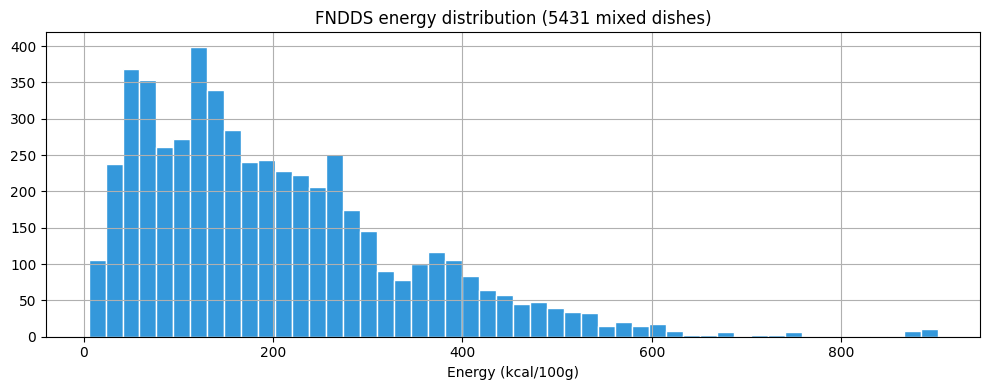

In [7]:
# Energy distribution
fig, ax = plt.subplots(figsize=(10, 4))
df_fndds["Energy [kcal]"].hist(bins=50, ax=ax, color="#3498db", edgecolor="white")
ax.set_xlabel("Energy (kcal/100g)")
ax.set_title("FNDDS energy distribution (5431 mixed dishes)")
plt.tight_layout()
plt.show()


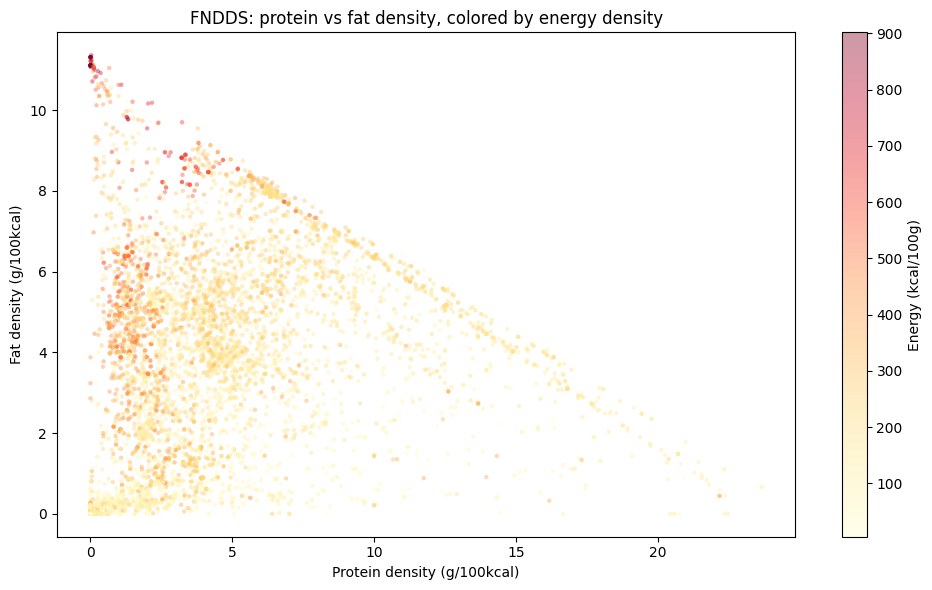

In [8]:
# Protein vs fat scatter per 100kcal
fig, ax = plt.subplots(figsize=(10, 6))
prot_col = "Protein_per_100kcal"
fat_col  = "Total_lipid_(fat)_per_100kcal"
if prot_col in df_fndds.columns and fat_col in df_fndds.columns:
    sc = ax.scatter(df_fndds[prot_col], df_fndds[fat_col],
                    c=df_fndds["Energy [kcal]"], cmap="YlOrRd",
                    alpha=0.4, s=10, edgecolors="none")
    plt.colorbar(sc, ax=ax, label="Energy (kcal/100g)")
ax.set_xlabel("Protein density (g/100kcal)")
ax.set_ylabel("Fat density (g/100kcal)")
ax.set_title("FNDDS: protein vs fat density, colored by energy density")
plt.tight_layout()
plt.show()


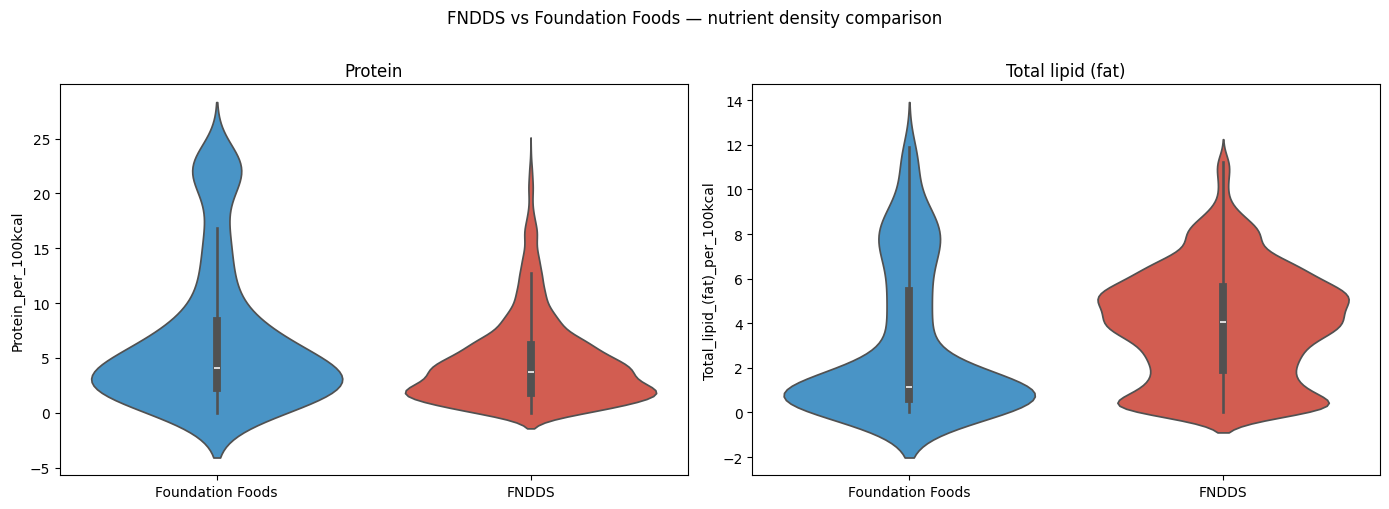

In [9]:
# Compare FNDDS vs Foundation Foods on key nutrients (violin plots)
df_foundation = pd.read_csv("foundation_analysis_ready.csv")
df_foundation["source"] = "Foundation Foods"
df_fndds_plot = df_fndds.copy()
df_fndds_plot["source"] = "FNDDS"

compare_cols = ["Protein_per_100kcal", "Total_lipid_(fat)_per_100kcal",
                "Fiber,_total_dietary_per_100kcal"]
compare_cols = [c for c in compare_cols if c in df_fndds.columns and c in df_foundation.columns]
df_combined = pd.concat([df_foundation[compare_cols + ["source"]],
                          df_fndds_plot[compare_cols + ["source"]]])

fig, axes = plt.subplots(1, len(compare_cols), figsize=(14, 5))
for ax, col in zip(axes, compare_cols):
    sns.violinplot(data=df_combined, x="source", y=col, ax=ax,
                   palette=["#3498db", "#e74c3c"], inner="box")
    ax.set_title(col.replace("_per_100kcal", "").replace("_", " "))
    ax.set_xlabel("")
plt.suptitle("FNDDS vs Foundation Foods — nutrient density comparison", y=1.01)
plt.tight_layout()
plt.show()


## 5. Dimensionality Reduction (5D PCA)

5 components explain ~70% of variance in mixed-dish nutrient profiles.

**Expected PC interpretation:**
- PC1: macro split (protein–fat axis)
- PC2: micronutrient richness (minerals, vitamins)
- PC3: plant vs. animal profile (fiber/potassium vs. cholesterol/B12)
- PC4–PC5: capture remaining macro texture (sugar content, specific fat types)


In [10]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_fndds[density_cols])

pca5 = PCA(n_components=N_PCA_COMPONENTS, random_state=42)
X_pca5 = pca5.fit_transform(X_scaled)

for i in range(N_PCA_COMPONENTS):
    df_fndds[f"PCA{i+1}"] = X_pca5[:, i]

print("Cumulative explained variance:")
cum = np.cumsum(pca5.explained_variance_ratio_)
for i, (v, c) in enumerate(zip(pca5.explained_variance_ratio_, cum), 1):
    print(f"  PC{i}: {v*100:.1f}%  cumulative: {c*100:.1f}%")


Cumulative explained variance:
  PC1: 24.1%  cumulative: 24.1%
  PC2: 16.0%  cumulative: 40.1%
  PC3: 9.6%  cumulative: 49.7%
  PC4: 6.7%  cumulative: 56.3%
  PC5: 6.1%  cumulative: 62.4%


In [11]:
# Component loadings for PC1-PC5
loadings = pd.DataFrame(pca5.components_, columns=density_cols,
                         index=[f"PC{i}" for i in range(1, N_PCA_COMPONENTS+1)])
for pc in loadings.index:
    row = loadings.loc[pc].sort_values()
    print(f"\n{pc} — top 3 positive:")
    print(row.tail(3).round(3).to_string())
    print(f"{pc} — top 3 negative:")
    print(row.head(3).round(3).to_string())



PC1 — top 3 positive:
Fatty_acids_total_saturated_per_100kcal          0.298
Fatty_acids_total_monounsaturated_per_100kcal    0.348
Total_lipid_(fat)_per_100kcal                    0.378
PC1 — top 3 negative:
Carbohydrate_by_difference_per_100kcal   -0.353
Fiber_total_dietary_per_100kcal          -0.322
Potassium_K_per_100kcal                  -0.314

PC2 — top 3 positive:
Vitamin_D_(D2_+_D3)_per_100kcal          -0.145
Vitamin_B-12_per_100kcal                 -0.118
Carbohydrate_by_difference_per_100kcal    0.331
PC2 — top 3 negative:
Potassium_K_per_100kcal   -0.323
Protein_per_100kcal       -0.314
Calcium_Ca_per_100kcal    -0.299

PC3 — top 3 positive:
Cholesterol_per_100kcal     0.302
Protein_per_100kcal         0.400
Vitamin_B-12_per_100kcal    0.402
PC3 — top 3 negative:
Fatty_acids_total_polyunsaturated_per_100kcal   -0.357
Total_lipid_(fat)_per_100kcal                   -0.277
Fiber_total_dietary_per_100kcal                 -0.274

PC4 — top 3 positive:
Fatty_acids_total_polyu

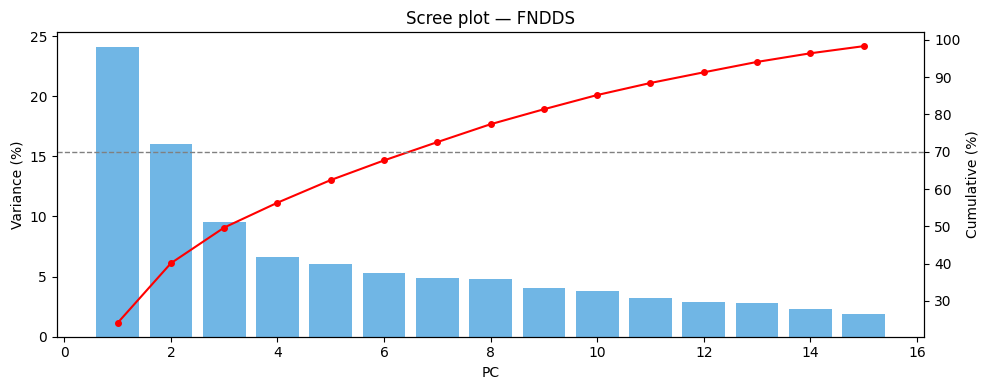

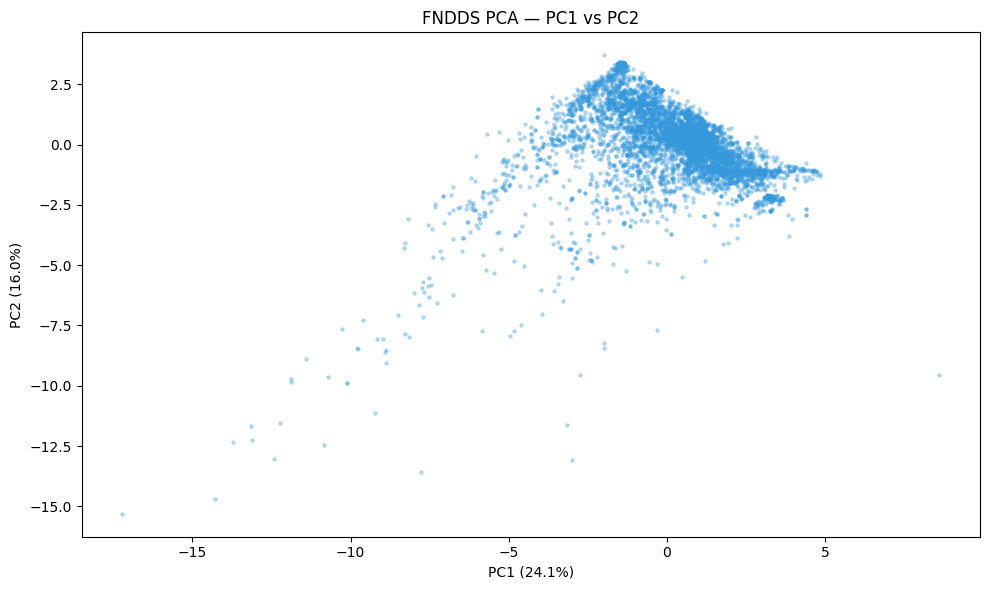

In [12]:
# Scree plot
pca_full = PCA(random_state=42).fit(X_scaled)
fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()
ax1.bar(range(1, 16), pca_full.explained_variance_ratio_[:15]*100,
        color="#3498db", alpha=0.7)
ax2.plot(range(1, 16), np.cumsum(pca_full.explained_variance_ratio_[:15])*100,
         "r-o", ms=4)
ax2.axhline(70, ls="--", color="grey", lw=1, label="70%")
ax1.set_xlabel("PC"); ax1.set_ylabel("Variance (%)"); ax2.set_ylabel("Cumulative (%)")
ax1.set_title("Scree plot — FNDDS")
plt.tight_layout(); plt.show()

# 2D scatter (PC1 vs PC2)
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df_fndds["PCA1"], df_fndds["PCA2"], alpha=0.3, s=5, color="#3498db")
ax.set_xlabel(f"PC1 ({pca5.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca5.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("FNDDS PCA — PC1 vs PC2")
plt.tight_layout(); plt.show()


## 6. Clustering

**Why cluster on scaled features, not PCA?**
PCA is lossy — it keeps only the top N components. Clustering on the full
scaled feature space preserves all nutritional variance and gives more
meaningful food families. PCA is kept only for visualization and the
recommendation engine distance metric.

**Why Hierarchical (Ward) for recommendation?**
K-Means clusters are spherical; Ward linkage builds a tree that better
captures elongated "food family" shapes (e.g., all pasta dishes cluster
together even if protein varies). We use Hierarchical_Cluster for `find_substitute`.


In [13]:
# K-Means with N_CLUSTERS_KMEANS=12
km = KMeans(n_clusters=N_CLUSTERS_KMEANS, random_state=42, n_init=10)
df_fndds["Cluster_KMeans"] = km.fit_predict(X_scaled)
print("K-Means cluster sizes:")
print(df_fndds["Cluster_KMeans"].value_counts().sort_index())


K-Means cluster sizes:
Cluster_KMeans
0      465
1     1673
2     1319
3      277
4        4
5      611
6        2
7      671
8      131
9       41
10     150
11       7
Name: count, dtype: int64


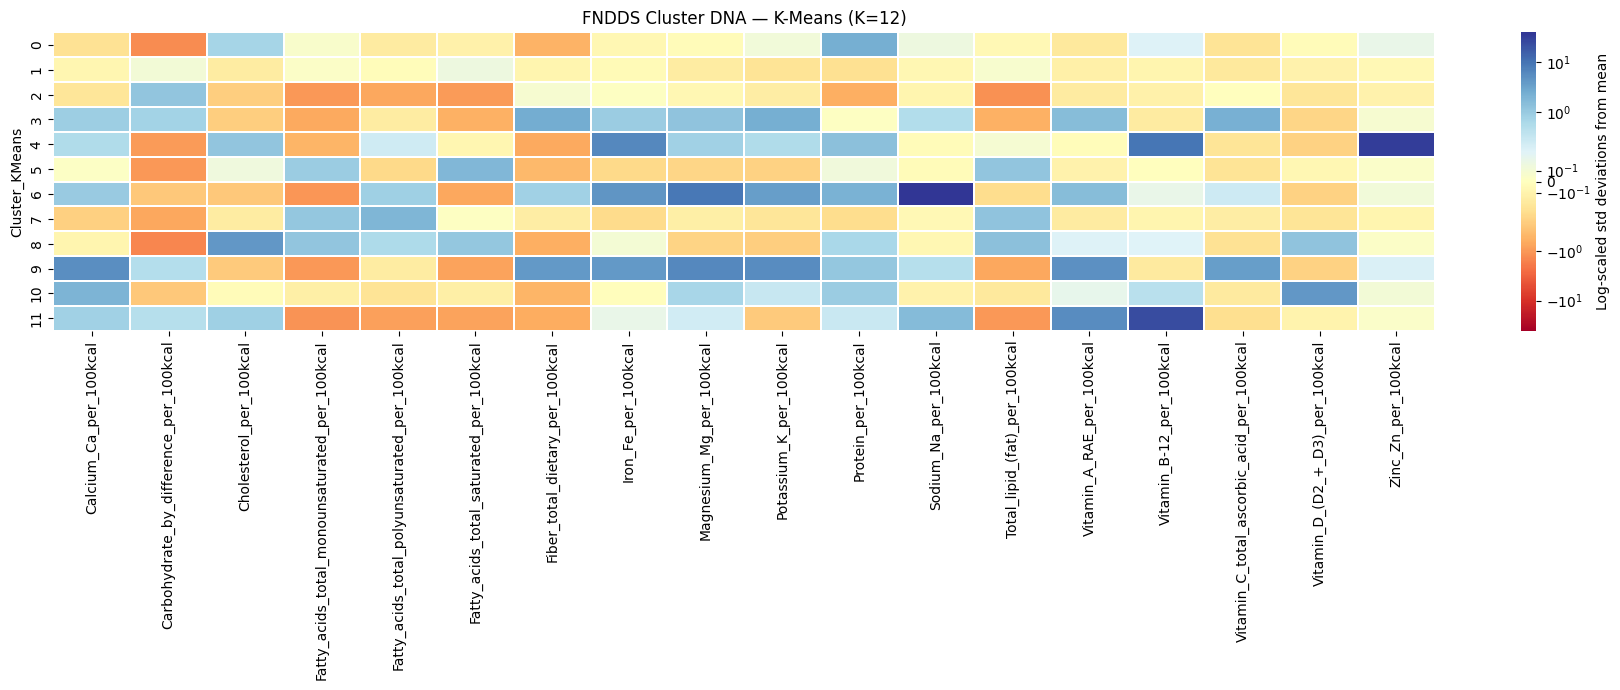


Cluster 0 (n=465, avg 156 kcal):
   Yogurt, Greek, NS as to type of milk, plain, Yogurt, Greek, low fat milk, plain, Yogurt, Greek, nonfat milk, plain, Yogurt, Greek, NS as to type of milk, flavors other than fruit, Yogurt, Greek, low fat milk, flavors other than fruit, Yogurt, Greek, nonfat milk, flavors other than fruit, Cheese, Cheddar, nonfat or fat free, Cheese, Parmesan, dry grated, fat free

Cluster 1 (n=1673, avg 217 kcal):
   Milk, condensed, sweetened, Soy milk, sweetened, Soy milk, chocolate, Yogurt, NFS, Yogurt, Greek, NS as to type of milk or flavor, Yogurt, whole milk, fruit, Yogurt, Greek, NS as to type of milk, fruit, Yogurt, Greek, whole milk, fruit

Cluster 2 (n=1319, avg 166 kcal):
   Yogurt, NS as to type of milk or flavor, Yogurt, NS as to type of milk, fruit, Yogurt, low fat milk, fruit, Yogurt, Greek, nonfat milk, fruit, Yogurt, NS as to type of milk, flavors other than fruit, Yogurt, low fat milk, flavors other than fruit, Yogurt, liquid, Yogurt tube

Cluster 3

In [14]:
# Cluster DNA heatmap — K-Means
scaled_df = pd.DataFrame(X_scaled, columns=density_cols, index=df_fndds.index)
scaled_df["Cluster_KMeans"] = df_fndds["Cluster_KMeans"]
km_fingerprints = scaled_df.groupby("Cluster_KMeans").mean()

fig, ax = plt.subplots(figsize=(18, 7))
vmax = km_fingerprints.abs().max().max()
sns.heatmap(km_fingerprints, cmap="RdYlBu",
            norm=SymLogNorm(linthresh=0.5, vmin=-vmax, vmax=vmax),
            linewidths=0.3, ax=ax,
            cbar_kws={"label": "Log-scaled std deviations from mean"})
ax.set_title("FNDDS Cluster DNA — K-Means (K=12)")
plt.tight_layout(); plt.show()

# Example foods per cluster
for c in sorted(df_fndds["Cluster_KMeans"].unique()):
    sub = df_fndds[df_fndds["Cluster_KMeans"] == c]
    print(f"\nCluster {c} (n={len(sub)}, avg {sub['Energy [kcal]'].mean():.0f} kcal):")
    print("  ", ", ".join(sub["description"].head(8).tolist()))


In [15]:
# Hierarchical (Agglomerative Ward)
agg = AgglomerativeClustering(
    n_clusters=N_CLUSTERS_HIERARCHICAL, metric="euclidean", linkage="ward"
)
df_fndds["Hierarchical_Cluster"] = agg.fit_predict(X_scaled)
print("Hierarchical cluster sizes:")
print(df_fndds["Hierarchical_Cluster"].value_counts().sort_index())


Hierarchical cluster sizes:
Hierarchical_Cluster
0      347
1     1136
2      401
3       36
4      114
5      764
6        4
7        7
8        2
9     1520
10     648
11     372
Name: count, dtype: int64


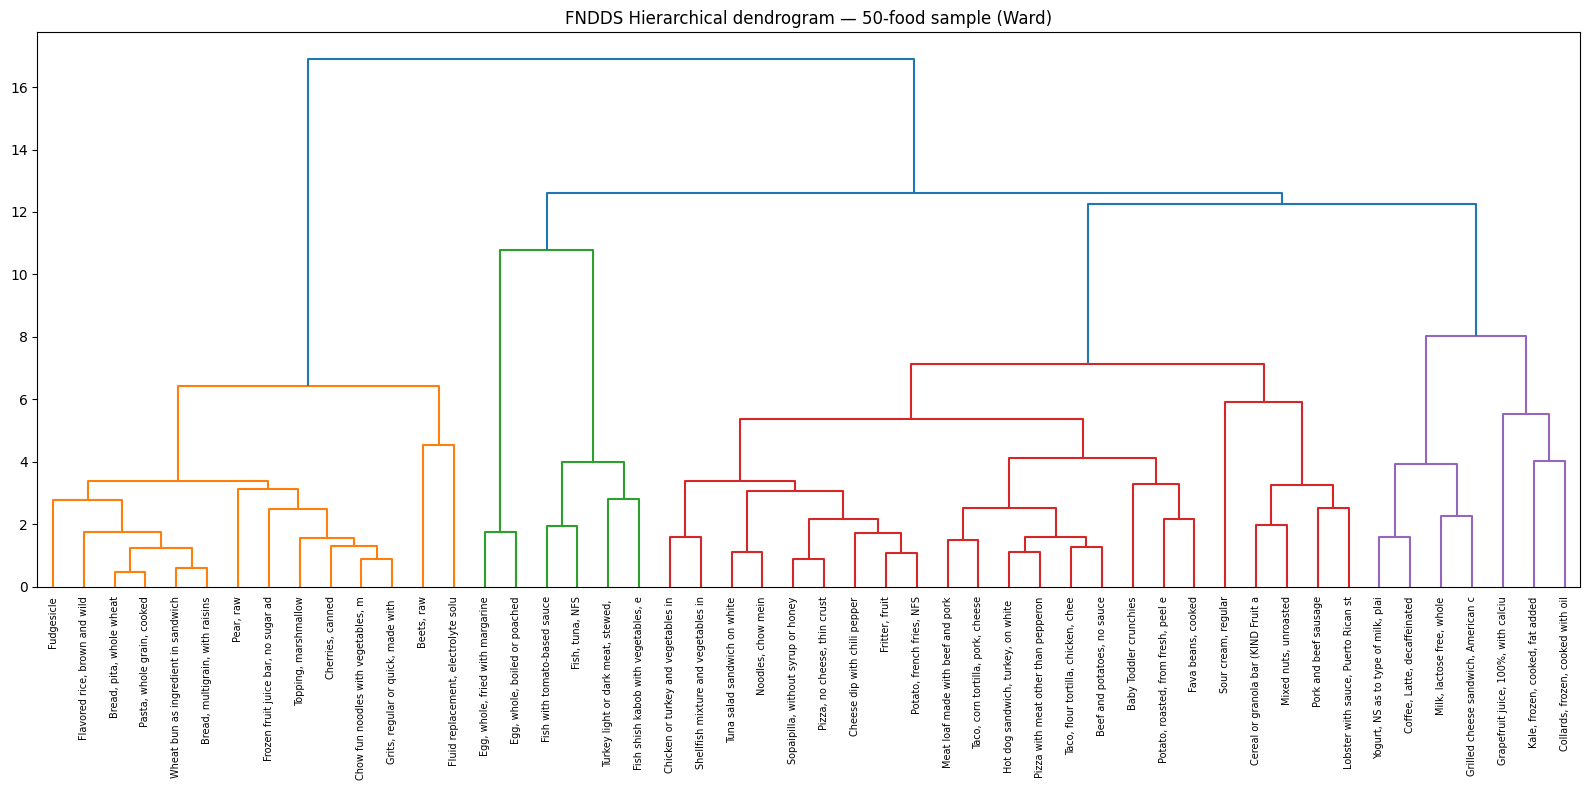

In [16]:
# Dendrogram on 50-sample subset
sample_idx    = df_fndds.sample(50, random_state=42).index
X_sample      = X_scaled[df_fndds.index.get_indexer(sample_idx)]
sample_labels = df_fndds.loc[sample_idx, "description"].str[:35].tolist()

linked = linkage(X_sample, method="ward")
fig, ax = plt.subplots(figsize=(16, 8))
dendrogram(linked, labels=sample_labels, ax=ax, leaf_rotation=90, leaf_font_size=7)
ax.set_title("FNDDS Hierarchical dendrogram — 50-food sample (Ward)")
plt.tight_layout(); plt.show()


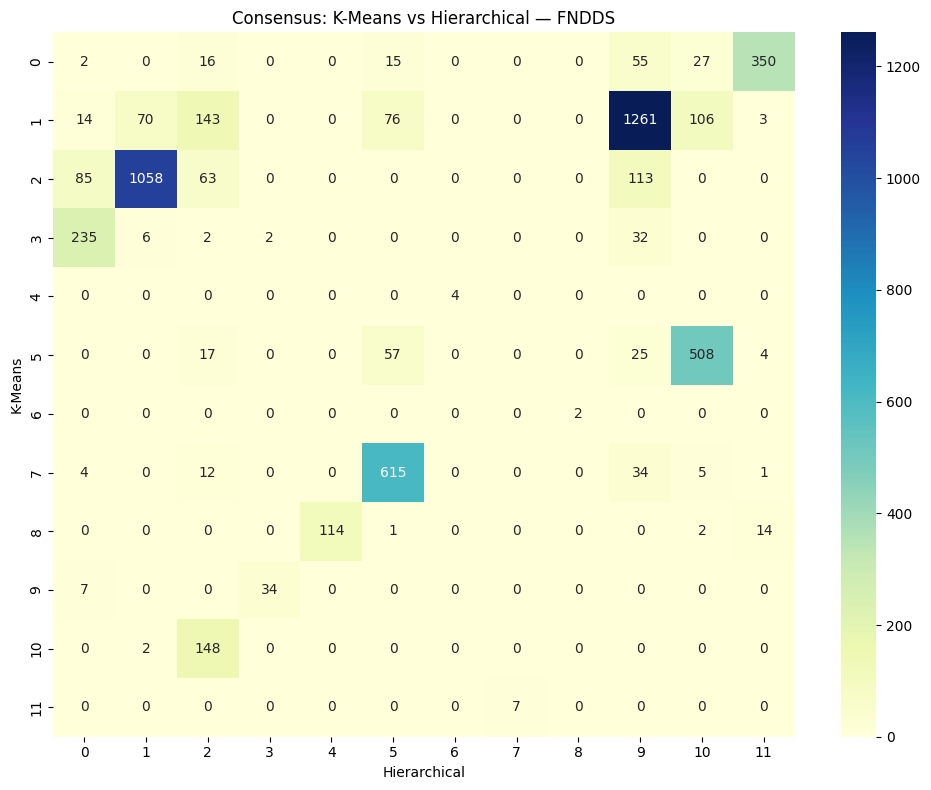

In [17]:
# Consensus heatmap: K-Means vs Hierarchical
ctab = pd.crosstab(df_fndds["Cluster_KMeans"], df_fndds["Hierarchical_Cluster"],
                   rownames=["K-Means"], colnames=["Hierarchical"])
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(ctab, annot=True, fmt="d", cmap="YlGnBu", ax=ax)
ax.set_title("Consensus: K-Means vs Hierarchical — FNDDS")
plt.tight_layout(); plt.show()


## 7. Recommendation Engine

`find_substitute` finds nutritionally superior alternatives for any mixed dish.

**Algorithm (patched):**
1. Fuzzy search the target food by name (str.contains, case-insensitive; take iloc[0])
2. **[PATCH 1]** Semantic pre-filter: restrict the entire FNDDS to the top
   `SEMANTIC_POOL_SIZE` dishes most semantically similar to the target name
   (bi-encoder cosine similarity on cached embeddings). This prevents a
   "Double cheeseburger" from receiving a "Shepherd's pie" recommendation.
3. Further restrict to same Hierarchical cluster (same nutritional family)
4. Compute Euclidean distance in 5D PCA space (nutritional similarity)
5. Keep top `similarity_percentile` most similar foods ("first cousins" window)
6. Require lower calories than target
7. Rank by composite health score: `2*potassium + 3*fiber - 2*sat_fat - sodium/100`
8. **[PATCH 2]** Report all deltas (calories, CO2, price) per `REFERENCE_PORTION_KCAL`
   standardised portion so comparisons are energy-equivalent regardless of water content

## Section 7: Healthier Substitute Recommendation Engine

### Algorithm Description

Given a query meal name (e.g., "Double cheeseburger"), the engine finds nutritionally superior alternatives within the same broad meal category using a three-stage pipeline:

**Stage 1 — Semantic candidate retrieval**
The query is encoded with the bi-encoder (`all-MiniLM-L6-v2`) and compared against pre-computed embeddings of all 5431 FNDDS dish names. The top `SEMANTIC_POOL_SIZE = 200` semantically similar candidates are retained. This pool is intentionally large to avoid filtering out nutritionally good options that happen to use different terminology.

**Stage 2 — Nutrient distance filtering**
Each candidate's nutrient density profile (22 features, standardized) is compared against the query food using Euclidean distance in PCA-reduced space. This ensures substitutes are genuinely similar meals — a healthier pizza rather than a completely different food category. Candidates outside the `SIMILARITY_PERCENTILE = 0.1` threshold (i.e., too nutritionally dissimilar) are dropped.

**Stage 3 — Dietary win ranking**
Remaining candidates are ranked by a composite of per-portion improvements over the query food across five key metrics: potassium, fiber (maximize), saturated fat, sodium (minimize), and calorie density. All comparisons use `REFERENCE_PORTION_KCAL = 500` — a fixed energy-equivalent portion — so that results are not distorted by water content differences between dishes.

When CO2 and price data are available (Section 9), the engine additionally flags candidates with >20% CO2 reduction (`[ECO WIN]`) or >10% price reduction (`[BUDGET WIN]`) per 500-kcal portion.

In [18]:
PCA_COLS = ["PCA1", "PCA2", "PCA3", "PCA4", "PCA5"]


def find_substitute(
    target_search: str,
    df: pd.DataFrame,
    top_n: int = 5,
    similarity_percentile: float = SIMILARITY_PERCENTILE,
    extended: bool = False,
    portion_kcal: float = REFERENCE_PORTION_KCAL,
) -> None:
    """
    Find nutritionally superior substitutes for a given mixed dish.

    Parameters
    ----------
    target_search : str
        Case-insensitive substring to find the target dish.
    df : pd.DataFrame
        Full FNDDS dataframe (df_fndds after CO2/price merge).
    top_n : int
        Maximum number of recommendations to print.
    similarity_percentile : float
        Fraction of same-cluster foods to consider as "nutritional cousins".
    extended : bool
        If True, show CO2 and price deltas and eco/budget win flags.
    portion_kcal : float
        Reference energy portion for delta calculations (default 500 kcal).
    """
    matches = df[df["description"].str.contains(target_search, case=False, na=False)]
    if matches.empty:
        print(f"No food found matching: '{target_search}'")
        return

    target = matches.iloc[0]
    t_kcal = target["Energy [kcal]"]
    target_pca = target[PCA_COLS].values

    # ── PATCH 1: semantic pre-filter ──────────────────────────────────────────
    # Narrow the entire dataset to semantically coherent dishes before
    # computing nutritional distances. Prevents cross-category substitutions
    # (e.g. burger → shepherd's pie).
    semantically_similar = _semantic_filter(target["description"], df)

    # Further restrict to same nutritional cluster.
    family = semantically_similar[
        semantically_similar["Hierarchical_Cluster"] == target["Hierarchical_Cluster"]
    ].copy()

    # Graceful fallback if semantic filter + cluster constraint empties the pool.
    if family.empty:
        print(f"[warning] Semantic filter produced no candidates in cluster "
              f"{target['Hierarchical_Cluster']} — falling back to full cluster.")
        family = df[df["Hierarchical_Cluster"] == target["Hierarchical_Cluster"]].copy()

    # ── Distance + calorie filter (unchanged logic) ───────────────────────────
    family["_dist"] = family.apply(
        lambda r: euclidean(target_pca, r[PCA_COLS].values), axis=1
    )
    cousin_thresh = family["_dist"].quantile(similarity_percentile)
    candidates = family[
        (family["_dist"] <= cousin_thresh) &
        (family["Energy [kcal]"] < t_kcal) &
        (family["fdcId"] != target["fdcId"])
    ].copy()

    if candidates.empty:
        print(f"No substitutes found for '{target['description']}'")
        return

    # ── Health score ranking (unchanged) ─────────────────────────────────────
    def health_score(row):
        return (row.get("Potassium_K_per_100kcal", 0) * 2 +
                row.get("Fiber_total_dietary_per_100kcal", 0) * 3 -
                row.get("Fatty_acids_total_saturated_per_100kcal", 0) * 2 -
                row.get("Sodium_Na_per_100kcal", 0) / 100)

    candidates["_score"] = candidates.apply(health_score, axis=1)
    recs = candidates.nlargest(top_n, "_score")

    # ── PATCH 2: pre-compute per-portion values for the target ────────────────
    t_pot   = target.get("Potassium_K_per_100kcal", 0)
    t_fib   = target.get("Fiber_total_dietary_per_100kcal", 0)
    t_sat   = target.get("Fatty_acids_total_saturated_per_100kcal", 0)
    t_sod   = target.get("Sodium_Na_per_100kcal", 0)
    t_co2   = target.get("co2_kg_final", float("nan"))
    t_price = target.get("price_per_kg",  float("nan"))

    # Grams of target food needed to reach the reference energy portion.
    t_grams = (portion_kcal / t_kcal * 100) if t_kcal > 0 else float("nan")

    # CO2 and price per reference portion.
    # co2 is in kg/kg = kg/1000g, so per-100g = co2/10; then scale to portion grams.
    t_co2_portion   = (t_co2   / 10.0 * t_grams / 100.0) if not pd.isna(t_co2)   else float("nan")
    t_price_portion = (t_price / 10.0 * t_grams / 100.0) if not pd.isna(t_price) else float("nan")

    print(f"TARGET: {target['description'].upper()}")
    print(f"  [Energy density: {t_kcal:.1f} kcal/100g  |  "
          f"≈ {t_grams:.0f} g per {portion_kcal:.0f}-kcal portion]")
    print(f"  [Potassium: {t_pot:.2f} mg/100kcal | Fiber: {t_fib:.2f} g/100kcal | "
          f"SatFat: {t_sat:.2f} g/100kcal | Sodium: {t_sod:.2f} mg/100kcal]")
    if extended and not pd.isna(t_co2):
        print(f"  [CO2: {t_co2:.2f} kg/kg  →  {t_co2_portion:.3f} kg per {portion_kcal:.0f}-kcal portion | "
              f"Price: ${t_price:.2f}/kg  →  ${t_price_portion:.2f} per portion]")
    print("=" * 90)

    for rank, (_, row) in enumerate(recs.iterrows(), 1):
        r_kcal  = row["Energy [kcal]"]
        r_grams = (portion_kcal / r_kcal * 100) if r_kcal > 0 else float("nan")
        r_pot   = row.get("Potassium_K_per_100kcal", 0)
        r_fib   = row.get("Fiber_total_dietary_per_100kcal", 0)
        r_sat   = row.get("Fatty_acids_total_saturated_per_100kcal", 0)
        r_sod   = row.get("Sodium_Na_per_100kcal", 0)
        r_co2   = row.get("co2_kg_final", float("nan"))
        r_price = row.get("price_per_kg",  float("nan"))

        # ── PATCH 2: per-portion deltas ───────────────────────────────────────
        r_co2_portion   = (r_co2   / 10.0 * r_grams / 100.0) if not pd.isna(r_co2)   else float("nan")
        r_price_portion = (r_price / 10.0 * r_grams / 100.0) if not pd.isna(r_price) else float("nan")

        grams_saved = (t_grams - r_grams) if not (pd.isna(t_grams) or pd.isna(r_grams)) else float("nan")

        eco_win = budget_win = False
        if extended:
            eco_win = (
                not pd.isna(t_co2_portion) and not pd.isna(r_co2_portion) and
                (t_co2_portion - r_co2_portion) / (t_co2_portion + 1e-9) > 0.20
            )
            budget_win = (
                not pd.isna(t_price_portion) and not pd.isna(r_price_portion) and
                (t_price_portion - r_price_portion) / (t_price_portion + 1e-9) > 0.10
            )

        flags = ""
        if extended:
            flags = "  " + "  ".join(filter(None, [
                "[ECO WIN]"    if eco_win    else "",
                "[BUDGET WIN]" if budget_win else "",
            ]))

        print(f"OPTION {rank}: {row['description'][:65]}{flags}")
        print(f"   Similarity: {'Very High' if row['_dist'] < 0.5 else 'Moderate'} "
              f"(dist={row['_dist']:.2f})")
        print(f"   DIETARY WINS  (per {portion_kcal:.0f}-kcal portion):")
        print(f"      ENERGY:     {r_kcal - t_kcal:+.1f} kcal/100g  "
              f"→  eat {abs(grams_saved):.0f} g {'less' if grams_saved > 0 else 'more'} "
              f"for the same {portion_kcal:.0f} kcal")
        print(f"      POTASSIUM:  {r_pot - t_pot:+.2f} mg/100kcal")
        print(f"      FIBER:      {r_fib - t_fib:+.2f} g/100kcal")
        print(f"      SAT_FAT:    {r_sat - t_sat:+.2f} g/100kcal")
        print(f"      SODIUM:     {r_sod - t_sod:+.1f} mg/100kcal")
        if extended:
            if not pd.isna(r_co2_portion):
                print(f"      CO2:        {r_co2_portion:.3f} vs {t_co2_portion:.3f} kg "
                      f"per {portion_kcal:.0f}-kcal portion  ({r_co2_portion - t_co2_portion:+.3f})")
            if not pd.isna(r_price_portion):
                print(f"      PRICE:      ${r_price_portion:.2f} vs ${t_price_portion:.2f} "
                      f"per {portion_kcal:.0f}-kcal portion  ({r_price_portion - t_price_portion:+.2f})")
        print("-" * 90)


print("find_substitute (patched) defined.")


find_substitute (patched) defined.


### Test: 5 foods

In [19]:
for food in ["Double cheeseburger", "Pizza, cheese", "Fried rice",
             "Macaroni and cheese", "Chicken, fried"]:
    print()
    find_substitute(food, df_fndds)



TARGET: DOUBLE CHEESEBURGER, ON WHITE BUN, 2 SMALL PATTIES
  [Energy density: 296.0 kcal/100g  |  ≈ 169 g per 500-kcal portion]
  [Potassium: 81.42 mg/100kcal | Fiber: 0.17 g/100kcal | SatFat: 2.54 g/100kcal | Sodium: 139.19 mg/100kcal]
OPTION 1: Lamb shish kabob with vegetables, excluding potatoes
   Similarity: Moderate (dist=0.63)
   DIETARY WINS  (per 500-kcal portion):
      ENERGY:     -134.0 kcal/100g  →  eat 140 g more for the same 500 kcal
      POTASSIUM:  +82.16 mg/100kcal
      FIBER:      +0.32 g/100kcal
      SAT_FAT:    -0.01 g/100kcal
      SODIUM:     -2.2 mg/100kcal
------------------------------------------------------------------------------------------
OPTION 2: Beef taco filling: beef, cheese, tomato, taco sauce
   Similarity: Very High (dist=0.48)
   DIETARY WINS  (per 500-kcal portion):
      ENERGY:     -115.0 kcal/100g  →  eat 107 g more for the same 500 kcal
      POTASSIUM:  +69.41 mg/100kcal
      FIBER:      +0.33 g/100kcal
      SAT_FAT:    +0.37 g/100kc

### How to read the output

Each result block shows one substitute option with:
- **Similarity**: whether the candidate is semantically very close ("Very High", dist < 0.5) or moderately related to the query. Lower distance = more similar meal type.
- **ENERGY delta**: how many fewer grams you need to eat of the substitute to get the same 500 kcal. A positive "eat X g less" means the substitute is more calorie-dense — relevant for satiety.
- **POTASSIUM / FIBER deltas**: positive = more per 100 kcal in the substitute. These are the primary "dietary win" signals.
- **SAT_FAT / SODIUM deltas**: negative = less per 100 kcal in the substitute. These are the primary "dietary risk reduction" signals.

For example, a substitute for "Double cheeseburger" with `SAT_FAT: -3.2 g/100kcal` means you get substantially less saturated fat per unit of energy — a meaningful improvement for cardiovascular health — while eating a meal that is semantically and culinarily similar. The engine does not recommend eating broccoli instead of a burger; it recommends a better burger or a similar sandwich.

**Limitations to keep in mind:** Because CO2 and price mappings for mixed dishes are approximate (see Methodology section), the eco/budget win flags in Section 9 should be treated as directional signals rather than precise estimates. The nutrient-based recommendations (Section 7) do not carry this limitation — FNDDS nutrient data is measured, not estimated.

## 8. CO2 and Price Integration (Best Effort)

FNDDS has 5431 mixed dishes vs AGRIBALYSE's 2454 products. Coverage will
be lower than for Foundation Foods. For mixed dishes, group-level CO2 is
often the best achievable — reasonable because the CO2 footprint of a dish
is dominated by its main protein component, which the group label captures.


In [20]:
# Load AGRIBALYSE and FMAP
long_key = "Synthèse\nRésultats d'impacts pour 1 kg de produit consommé chez le consommateur, intègrant notamment les pertes aux étapes intermédiaires.\nPour en savoir plus, voir la documentation scientifique."

df_raw_agri = pd.read_excel(AGRI_PATH, sheet_name="Synthese", header=[1, 2])
df_agri = pd.DataFrame({
    "lci_name":    df_raw_agri[(long_key, "LCI Name")],
    "group":       df_raw_agri[(long_key, "Groupe d'aliment")],
    "season_code": df_raw_agri[(long_key,
        "code saison (0 : hors saison ; 1 : de saison ; 2 : mix de consommation FR)")],
    "co2_kg":      df_raw_agri[("Changement climatique", "kg CO2 eq/kg de produit")],
}).query("season_code == @AGRIBALYSE_SEASON_CODE").reset_index(drop=True)

df_fmap_raw = pd.read_excel("FMAP.xlsx", sheet_name="Data")
df_prices = (
    df_fmap_raw[
        (df_fmap_raw["Metroregion_name"] == "National") &
        (df_fmap_raw["Year"] >= FMAP_MIN_YEAR)
    ]
    .groupby("EFPG_name")["Unit_value_mean_unwtd"].mean()
    .reset_index()
    .rename(columns={"Unit_value_mean_unwtd": "price_per_100g", "EFPG_name": "efpg_name"})
)
df_prices["price_per_kg"] = df_prices["price_per_100g"] * 10

print("AGRIBALYSE:", df_agri.shape, "| FMAP:", df_prices.shape)


AGRIBALYSE: (2454, 4) | FMAP: (90, 3)


In [21]:
fndds_names = df_fndds["description"].tolist()
agri_names  = df_agri["lci_name"].tolist()

df_co2_matched = match_with_reranking(
    source_names = fndds_names,
    target_names = agri_names,
    target_df    = df_agri,
    result_cols  = {"lci_name": "co2_match", "group": "co2_group", "co2_kg": "co2_kg"},
    label        = "CO2-FNDDS",
)
df_co2_matched.rename(columns={"source": "usda_description"}, inplace=True)

print("\nCO2 matching confidence distribution:")
print(df_co2_matched["bi_encoder_conf"].describe().round(3))
high_conf = (df_co2_matched["bi_encoder_conf"] >= 0.70).sum()
print(f"\nHigh-confidence CO2 matches (>=0.70): {high_conf}/{len(fndds_names)} "
      f"({high_conf/len(fndds_names)*100:.1f}%)")


Loading sentence transformers (first call only)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cross-encoder/stsb-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Batches:   0%|          | 0/168 [00:00<?, ?it/s]

Batches:   0%|          | 0/77 [00:00<?, ?it/s]

[CO2-FNDDS] Cross-encoder re-ranking 53510 pairs...


Batches:   0%|          | 0/1673 [00:00<?, ?it/s]


CO2 matching confidence distribution:
count    5351.000
mean        0.664
std         0.109
min         0.260
25%         0.599
50%         0.660
75%         0.730
max         1.000
Name: bi_encoder_conf, dtype: float64

High-confidence CO2 matches (>=0.70): 1860/5351 (34.8%)


In [22]:
df_co2_matched["match_quality"] = np.where(
    (df_co2_matched["cross_encoder_score"] >= 0) & (df_co2_matched["bi_encoder_conf"] >= 0.60),
    "high",
    np.where(df_co2_matched["bi_encoder_conf"] >= 0.75, "medium", "low"),
)

df_co2_corrected, group_means = apply_co2_corrections(
    df_matched           = df_co2_matched,
    df_agri              = df_agri,
    group_labels         = AGRIBALYSE_GROUP_LABELS,
    overrides            = CO2_PRODUCT_OVERRIDES,
    suspicious_threshold = CO2_SUSPICIOUS_THRESHOLD,
)
print("Correction layer distribution:")
print(df_co2_corrected["correction_layer"].value_counts())


Correction layer distribution:
correction_layer
layer3_kept              5248
layer1_product             55
layer1_group_fallback      48
Name: count, dtype: int64


In [23]:
df_price_matched = match_with_reranking(
    source_names = fndds_names,
    target_names = df_prices["efpg_name"].tolist(),
    target_df    = df_prices,
    result_cols  = {"efpg_name": "price_match", "price_per_kg": "price_per_kg"},
    label        = "Price-FNDDS",
)
df_price_matched.rename(columns={"source": "usda_description"}, inplace=True)
print("Price matching confidence:")
print(df_price_matched["bi_encoder_conf"].describe().round(3))


[Price-FNDDS] Encoding 5351 source + 90 target names...


Batches:   0%|          | 0/168 [00:00<?, ?it/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

[Price-FNDDS] Cross-encoder re-ranking 53510 pairs...


Batches:   0%|          | 0/1673 [00:00<?, ?it/s]

Price matching confidence:
count    5351.000
mean        0.526
std         0.119
min         0.119
25%         0.456
50%         0.530
75%         0.603
max         0.940
Name: bi_encoder_conf, dtype: float64


In [24]:
# Merge CO2 and price onto df_fndds
df_fndds = (
    df_fndds
    .merge(df_co2_corrected[["usda_description", "co2_match", "co2_group",
                               "co2_kg", "co2_kg_final", "correction_layer"]],
           left_on="description", right_on="usda_description", how="left")
    .drop(columns="usda_description", errors="ignore")
    .merge(df_price_matched[["usda_description", "price_match", "price_per_kg"]],
           left_on="description", right_on="usda_description", how="left")
    .drop(columns="usda_description", errors="ignore")
)

#add normalised price and co2 per 100kcal
# Energy density: 'Energy [kcal]' is per 100g → multiply by 10 to get kcal/kg
df_fndds["kcal_per_kg"] = df_fndds["Energy [kcal]"] * 10

# Guard against zero-calorie rows (e.g. water, spices) to avoid division by zero
_eps = 1e-9

# Objective 1 — price per 100 kcal (minimize)
df_fndds["price_per_100kcal"] = (df_fndds["price_per_kg"] / (df_fndds["kcal_per_kg"] + _eps)) * 100

# Objective 2 — CO2 per 100 kcal (minimize)
df_fndds["co2_per_100kcal"] = (df_fndds["co2_kg_final"] / (df_fndds["kcal_per_kg"] + _eps)) * 100

print("df_fndds with CO2+price shape:", df_fndds.shape)
print("CO2 coverage:", df_fndds["co2_kg_final"].notna().sum(), "/", len(df_fndds))
print("Price coverage:", df_fndds["price_per_kg"].notna().sum(), "/", len(df_fndds))
print("CO2 per 100kcal stats:")
print(df_fndds["co2_per_100kcal"].describe().round(3))
print("Price per 100kcal stats:")
print(df_fndds["price_per_100kcal"].describe().round(3))

df_fndds.to_csv("fndds_clustered.csv", index=False)
df_fndds.to_csv("fndds_with_co2_price.csv", index=False)
print("\nSaved: fndds_clustered.csv, fndds_with_co2_price.csv")


df_fndds with CO2+price shape: (5351, 56)
CO2 coverage: 5351 / 5351
Price coverage: 5351 / 5351
CO2 per 100kcal stats:
count    5351.000
mean        0.328
std         0.587
min         0.000
25%         0.085
50%         0.170
75%         0.317
max        12.000
Name: co2_per_100kcal, dtype: float64
Price per 100kcal stats:
count    5351.000
mean        0.522
std         0.831
min         0.008
25%         0.176
50%         0.330
75%         0.543
max        25.060
Name: price_per_100kcal, dtype: float64

Saved: fndds_clustered.csv, fndds_with_co2_price.csv


In [25]:
# ── PATCH 1: build semantic index ───────────────────────────────────────────
# Must be called after df_fndds is fully assembled with CO2 + price columns.
# Encodes all 5431 dish names once; find_substitute() reuses the cache.
build_semantic_index(df_fndds)

Building semantic index for 5351 FNDDS dishes...


Batches:   0%|          | 0/21 [00:00<?, ?it/s]

Semantic index ready.


## 9. Extended Recommendation Engine (with CO2 + Price)

When CO2 and price data are available for both target and candidate foods,
`find_substitute` is extended to show:
- CO2 delta **per 500-kcal portion** (not per kg of raw mass)
- Price delta **per 500-kcal portion**
- "environmental win" flag if per-portion CO2 reduction > 20%
- "budget win" flag if per-portion price reduction > 10%

All deltas use `REFERENCE_PORTION_KCAL = 500` so comparisons are
energy-equivalent regardless of water content differences between dishes.

In [27]:
# Same function with extended=True adds CO2 + price deltas and eco/budget win flags
for food in ["Double cheeseburger", "Pizza, cheese", "Fried rice",
             "Macaroni and cheese", "Chicken, fried"]:
    print()
    find_substitute(food, df_fndds, extended=True)



TARGET: DOUBLE CHEESEBURGER, ON WHITE BUN, 2 SMALL PATTIES
  [Energy density: 296.0 kcal/100g  |  ≈ 169 g per 500-kcal portion]
  [Potassium: 81.42 mg/100kcal | Fiber: 0.17 g/100kcal | SatFat: 2.54 g/100kcal | Sodium: 139.19 mg/100kcal]
  [CO2: 14.10 kg/kg  →  2.382 kg per 500-kcal portion | Price: $11.16/kg  →  $1.88 per portion]
OPTION 1: Double hamburger, on wheat bun, 2 medium patties  
   Similarity: Very High (dist=0.35)
   DIETARY WINS  (per 500-kcal portion):
      ENERGY:     -10.0 kcal/100g  →  eat 6 g more for the same 500 kcal
      POTASSIUM:  +14.39 mg/100kcal
      FIBER:      +0.32 g/100kcal
      SAT_FAT:    -0.21 g/100kcal
      SODIUM:     -26.6 mg/100kcal
      CO2:        2.465 vs 2.382 kg per 500-kcal portion  (+0.083)
      PRICE:      $1.77 vs $1.88 per 500-kcal portion  (-0.11)
------------------------------------------------------------------------------------------
OPTION 2: Double cheeseburger, on wheat bun, 2 small patties  
   Similarity: Very High (dist=